#3장


목표는 간결하고, 효율적인 multi head attention을 구현하는 것이다.

encoder-decoder 구조에 RNN 기법을 적용하여 번역 작업을 하는 인공 신경망을 생각해보자. RNN 기법이 적용된 이러한 autoencoder의 encoder에서는 decoder로 하나의 입력을 보내는데, 이 encoder의 출력이자 decoder의 입력인 이 vector가 encoder에 입력된 sequence를 요약한 context vector이다. decoder는 이 context vector를 가지고 token을 예측하여 번역 작업을 수행한다.

이 방법에는 문제가 하나 있다. encoder에서는 입력 sequence내의 token을 순차적으로 처리해서 최종적인 context vector를 출력하는데, 이 context vector는 처음 처리한 token에 대한 기억은 희미해지고, 마지막에 처리한 token만이 선명하게 남아있는 상태로 decoder로 보내기에 decoder는 입력 sequence내의 초반에 나온 token에 대한 참조는 제대로 하지 못한다는 문제가 있다.

이러한 문제를 해결하기 위해 Bahdanau attention mechanism이 개발되었다. 이 기법은 간단하다. encoder-decoder RNN을 수정하여 decoding 단계마다 decoder가 선택적으로 입력 sequence의 서로 다른 부분을 참조할 수 있도록 하는 것이다. 즉 decoder에서 현재 출력 token을 생성하는 데 어떤 입력 token이 다른 token보다 더 중요한지 판단하고 이를 기반으로 출력 token을 생성할 수 있다는 의미이다.

transformer에는 Bahdanau attention mechanism에서 영감을 받은 self-attention mechanism이 포함되어 있다.

이 self-attention mechanism에서는 sequence의 표현을 게산할 때 입력 sequence에 있는 각 위치가 동일 sequence에 있는 다른 모든 위치와의 관련성을 고려하거나 주의를 기울일 수 있다.

self-attention에서 self는 하나의 input sequence에 있는 서로 다른 위치의 원소 사이에서 attention weight를 계산하는 방식을 의미한다. -> 입력 내 여러 부분 사이의 관계와 의존성을 평가하고 학습한다.

self-attention의 목표는 입력 sequence내의 다른 모든 입력 원소의 정보를 조합하여, 각각의 입력 원소에 대한 context vector를 계산하는 것이다(각 token에 대한 context vector는 그 token과 입력 sequence내의 다른 token들 사이의 관계를 나타내는 embedding vector이다. 이러한 context vector로 LLM이 다음 token을 생성하게 된다.). 이때 현재 출력에는 어떤 원소가 중요한 지에 대한 내용이 각 원소가 갖는 attention weight로 표현되며, 이는 학습이 가능하다.

이때 self-attention의 입력은 이미 각 token에 대한 embedding vector들이다.

In [1]:
#일단 weight가 없는 self-attention mechanism을 보겠다.
#먼저, 3차원 vector로 embedding된 input sequence가 다음과 같다고 가정
import torch
inputs=torch.tensor(
    [[0.43,0.15,0.89],
     [0.55,0.87,0.66],
     [0.57,0.85,0.64],
     [0.22,0.58,0.33],
     [0.77,0.25,0.10],
     [0.05,0.80,0.55]]
)

In [2]:
#다음으로는 attention score를 계산한다.
#input sequence내의 각 token을 query로 사용하여 그 token에 대한 context vector를 계산하는 것이 최종 목표일 때
#attention score는 query token과 input sequence내의 모든 token을 각각 내적하여 각각의 attention score을 계산한다.
#즉 x_2가 query token라 하면 x_2과 x_1을 내적하여 x_2와 x_1사이의 attention score를 계산한다.

query=inputs[1] #두 번째 input token을 query token으로 사용
attn_scores_2=torch.empty(inputs.shape[0])
print(inputs.shape[0])  #inputs의 행의 수
print(attn_scores_2)    #attention score 초기화
for i, x_i in enumerate(inputs):
  attn_scores_2[i]=torch.dot(x_i,query)
print(attn_scores_2)  #두 번째 input token을 query token으로 사용했을 때의 attention score가 출력된다.


6
tensor([-5.6816e+10,  3.2818e-07, -3.6271e+30,  6.6734e-24,  9.4051e-38,
         2.6443e-26])
tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [3]:
#위에서 계산한 attention score를 normalization한다.
#이를 통해 attention weight의 합이 1이 되도록 한다. 해석과 LLM 훈련의 안정성을 유지하기 위해

attn_weights_2_tmp=attn_scores_2/attn_scores_2.sum()
print("어텐션 가중치: ",attn_weights_2_tmp)
print("합:",attn_weights_2_tmp.sum())

어텐션 가중치:  tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
합: tensor(1.0000)


다음은 softmax 식이다.

vector y의 원소들은 y_1, y_2, y_3과 같이 표현된다.

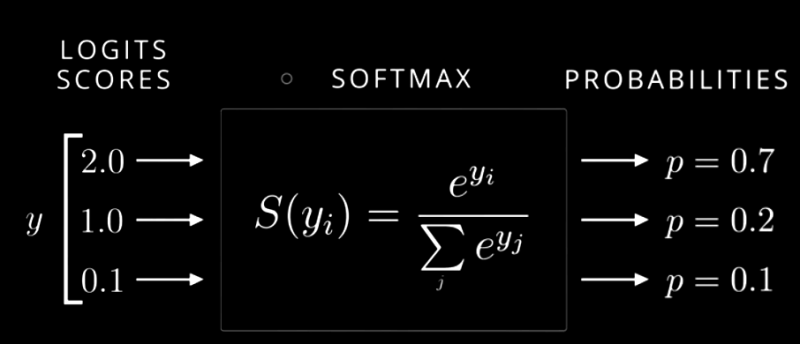

In [4]:
#실제로는 다음과 같이 softmax를 사용하여 normalization한다.

def softmax_naive(x):
  print(x)
  print(torch.exp(x).sum(dim=0))
  return torch.exp(x)/torch.exp(x).sum(dim=0)

attn_weights_2_naive=softmax_naive(attn_scores_2)
print("어텐션 가중치:",attn_weights_2_naive)
print("합:",attn_weights_2_naive.sum())

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
tensor(18.7453)
어텐션 가중치: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
합: tensor(1.)


In [5]:
#더 권장되는 softmax 함수
attn_weights_2=torch.softmax(attn_scores_2,dim=0)
print("어텐션 가중치:",attn_weights_2)
print("합:",attn_weights_2.sum())

어텐션 가중치: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
합: tensor(1.)


In [6]:
#이제 최종적인 목표인 현재 query token에 대한 context vector을 계산할 차례다.
#위에서 구한 attention weight를 입력 sequence의 그 위치에 해당하는 token에 곱한 후 모두 더해서
#두 번째 input token을 query token으로 사용했을 때의 그에 대한 context vector를 구한다.

query=inputs[1] #3차원 vector
context_vec_2=torch.zeros(query.shape)
print(context_vec_2)
for i,x_i in enumerate(inputs):
  #i번째 embedding vector와 i번째 attention_weight(상수값)을 곱한다.
  #이를 반복하여 더한다.
  context_vec_2+= attn_weights_2[i]*x_i
print(context_vec_2)

#위에서 input token의 embedding vector는 3차원 vector라 했고,
#attention score는 실수값이므로 각 3차원 vector에 그에 해당하는 attention score라는 실수값을 곱하고
#곱해서 나온 3차원 vector들을 다 더하면 밑의 결과와 같이 3차원 context vector가 생성된다.

tensor([0., 0., 0.])
tensor([0.4419, 0.6515, 0.5683])


In [7]:
#모든 input token에 대한 각각의 context vector를 계산하겠다(각 input token을 query로 설정하여 위 과정을 반복).
#각 context vector마다 attention score들을 따로 계산해야 한다.
#왜냐, 각 context vector를 계산하는 과정마다 query token이 달라지기 때문이다.

attn_scores=torch.empty(6,6)
for i,x_i in enumerate(inputs):
  for j, x_j in enumerate(inputs):
    attn_scores[i,j]=torch.dot(x_i,x_j)

print(attn_scores)
#이 matrix의 i번째 행은 i번째 input token을 query token으로 했을 때 모든 token에 대한 각각의 attention score가 원소로 정의되어 있다.
#결국 inputs라는 6x3 matrix는 자기 자신과 행렬곱하여 attn_scores라는 6x6 matrix을 만들어낸 것이다.
#6x3 @ 3x6 = 6x6

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [8]:
#위와 동일한 계산이지만 행렬 곱셈을 사용하면 더 효율적으로 계산할 수 있다.
attn_scores=inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [9]:
#normalization을 해보자.
attn_weights=torch.softmax(attn_scores,dim=-1)  #2차원 tensor일 때 열을 따라서 각 행의 값을 모두 더해 1이 되도록 normalization하도록 dim=-1로 지정
print(attn_weights)
print("각 행의 합:",attn_weights.sum(dim=-1))
print("각 열의 합:",attn_weights.sum(dim=0))


tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])
각 행의 합: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
각 열의 합: tensor([0.9220, 1.2970, 1.2788, 0.7974, 0.7540, 0.9508])


In [10]:
print(inputs)

tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])


    inputs이 다음과 같다.
    tensor([[0.4300, 0.1500, 0.8900],
            [0.5500, 0.8700, 0.6600],
            [0.5700, 0.8500, 0.6400],
            [0.2200, 0.5800, 0.3300],
            [0.7700, 0.2500, 0.1000],
            [0.0500, 0.8000, 0.5500]])
    all_context는 다음과 같다.
    tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])
    다음은 attn_weights 행렬 중 0번째 행이다.
    [0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452]

    all_context의 0번째 행 벡터는 다음과 같이 구한다.
    all_context[0]=0.2098*[0.4300, 0.1500, 0.8900] +
                   0.2006*[0.5500, 0.8700, 0.6600] +
                   0.1981*[0.5700, 0.8500, 0.6400] +
                   0.1242*[0.2200, 0.5800, 0.3300] +
                   0.1220*[0.7700, 0.2500, 0.1000] +
                   0.1452*[0.0500, 0.8000, 0.5500]
                  =[0.4421, 0.5931, 0.5790]

In [11]:
#위 계산에 대한 코드이다.
context_vector=torch.zeros(query.shape)
for i, x_i in enumerate(inputs):
  print(attn_weights[0][i],"*",x_i)
  context_vector+=attn_weights[0][i]*x_i
print(context_vector)

tensor(0.2098) * tensor([0.4300, 0.1500, 0.8900])
tensor(0.2006) * tensor([0.5500, 0.8700, 0.6600])
tensor(0.1981) * tensor([0.5700, 0.8500, 0.6400])
tensor(0.1242) * tensor([0.2200, 0.5800, 0.3300])
tensor(0.1220) * tensor([0.7700, 0.2500, 0.1000])
tensor(0.1452) * tensor([0.0500, 0.8000, 0.5500])
tensor([0.4421, 0.5931, 0.5790])


In [12]:
#이 attention weight에 대한 matrix와 input token에 대한 matrix를 행렬 곱하여 context vector에 대한 matrix를 계산한다.
all_context_vecs=attn_weights@inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


위와 같이 훈련이 없는 self-attention mechanism에 살을 붙여 훈련이 가능한 self-attention mechanism을 구현하겠다.

-> 훈련 가능한 weight를 가진 self-attention machanism은 위에서 구현한 attention과 같이 특정 input token에 대한 input vector의 weight 합으로 context vector를 계산한다. 이때 훈련 가능한 weight matrix를 통해 LLM 모델 내의 attention 모델이 좋은 context vector를 '생성하는 방법'을 배울 수 있다.

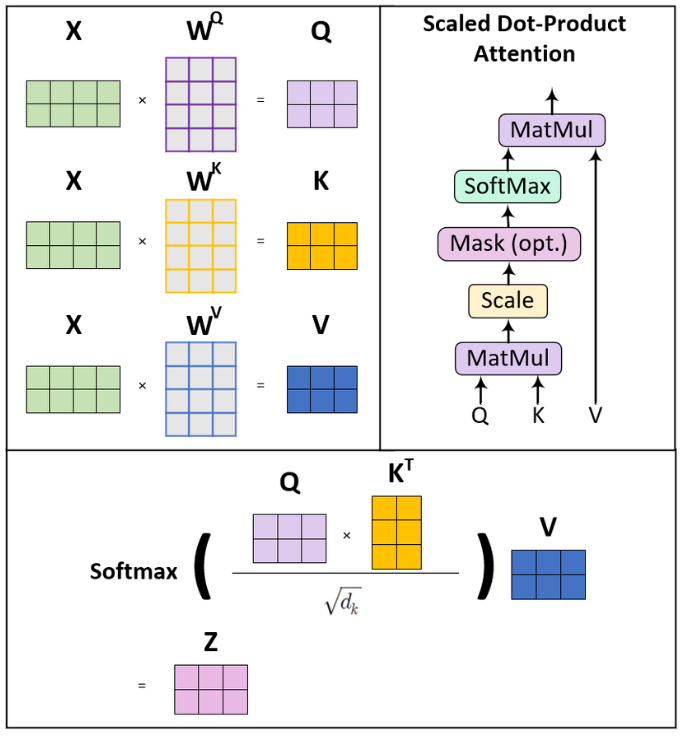

위 그림에서 보이듯 3개의 weight matrix인 Wq, Wk, Wv를 추가한다. 이 3개의 matrix과 input token embedding을 행렬 곱해 각각 query, key, value vector를 얻는다.

이때 이 weight는 attention weight와는 다르다. attention weight는 context vector가 다른 input token에 의존하는 정도를 결정한다. 그렇기에 attention weight는 query token에 따라 다른 값을 갖지만, weight matrix는 query token에 따라 바뀌지 않는다.

In [13]:
#지금부터 구현하는 self-attention mechanism은 scaled dot-product attention라 부르며, GPT와 대부분의 LLM에서 사용된다.
#이를 이해하기 위해 x2에 대한 context vector를 계산해보겠다.
#먼저 변수를 정의하겠다.

x_2=inputs[1]
d_in=inputs.shape[1]  #input embedding 크기를 3으로 설정
d_out=2 #output embedding 크기를 2로 설정

In [14]:
#weight matrix 3개를 각각 초기화 한다.
#(현재 코드 내에서)각 matrix의 크기는 3x2이다.
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in,d_out),requires_grad=False)
#여기서는 출력을 간단히 하기 위해 requires_grad=False로 지정했지만
#model training 시에는 requires_grad=True로 지정하여 훈련 과정에서 weight matrix을 업데이트해야 한다.

In [15]:
#x_2에 대한 query, key, value vector 계산
#x_2는 1x3이고, 각 matrix는 3x2이므로 계산 결과는 1x2가 된다.
query_2=x_2 @ W_query
key_2=x_2 @ W_key
value_2=x_2 @ W_value
print(query_2)  #두 번째 input token에 대한 query 출력

tensor([0.4306, 1.4551])


In [16]:
#두 번째 input token에 대한 query에 대한 attention weight를 게산하기 위해서는 모든 input token에 대한 key와 value vector가 필요하다.
keys = inputs @ W_key
values = inputs @ W_value
print("keys.shape:",keys.shape) #6개 embedding vector가 있을 때 각 vector의 key vector(1x2)
print("values.shape:",values.shape)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])


In [17]:
#이제 attention score를 계산하겠다.
#query token vector와 각 input token vector를 내적하여 각 input token에 대한 attention score를 구하는 것이 아닌
#위에서 계산한 두 번째 input token에 대한 query token vector와 각 input token에 대한 key vector를 내적하여 각 input token에 대한 attention score를 구한다.

#두 번째 input token에 대한 query token vector와 두 번째 input token에 대한 key vector를 내적하여 두 번째 input token에 대한 attention score를 구한다.
keys_2=keys[1]
attn_scores_22=query_2.dot(keys_2)
print(attn_scores_22)

tensor(1.8524)


In [18]:
#행렬 곱으로 두 번째 input token이 query token일 때의 모든 attention score를 구한다.
attn_scores_2=query_2 @ keys.T
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [19]:
#이제 attention score에서 attention weight를 구해보겠다.
#즉 attention score를 normalization 하겠다.

d_k=keys.shape[-1]
print(d_k)
attn_weights_2=torch.softmax(attn_scores_2/d_k**0.5,dim=-1)
print(attn_weights_2)

2
tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


In [20]:
#마지막으로 두 번째 input token이 query token일 때의 context vector를 구하겠다.
#각 input token의 value token과 attention weight를 곱한 뒤 모든 vector를 합하여 context vector를 구한다.
#이때 attetion weight가 각각의 value vector의 중요도에 대한 weight로 동작한다.

context_vec_2=attn_weights_2 @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


In [21]:
#위에서 구현한 self-attention mechanism을 하나의 class로 구성하였다.
import torch.nn as nn
class SelfAttention_v1(nn.Module):
  def __init__(self,d_in,d_out):  #weight matrix 초기화
    super().__init__()
    self.W_query=nn.Parameter(torch.rand(d_in,d_out))
    self.W_key=nn.Parameter(torch.rand(d_in,d_out))
    self.W_value=nn.Parameter(torch.rand(d_in,d_out))

  def forward(self,x):  #context vector 생성
    keys=x@self.W_key
    queries=x@self.W_query
    values=x@self.W_value
    attn_scores=queries@keys.T
    attn_weights=torch.softmax(
        attn_scores/keys.shape[-1]**0.5,dim=-1
    )
    context_vec=attn_weights@values
    return context_vec

In [22]:
#위 class 사용
torch.manual_seed(123)
sa_v1=SelfAttention_v1(d_in,d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


지금까지의 self-attention mechanism

훈련이 가능한 weight matrix인 Wq,Wk,Wv를 각 token의 embedding vector에 행렬 곱하여 각 token에 대한 query, key ,value vector를 계산한다.

그리고 각 query vector에 대한 context vector를 계산하는 것이 self-attention mechanism의 목표이다.

이는 다음과 같은 과정으로 진행된다.

i번째 token의 query vector에 대한 context vector를 계산하고자 한다면, 일단 query vector i와 모든 입력 token에 대해 그 token의 key vector를 각각 내적하여 각 token에 대한 attention score를 구한다.

그리고 softmax 함수를 이용하여 normalization을 진행하여 attention weight를 구한다. 이제 각 token의 value vector와 그 token의 attention weight(실수값)를 곱하고, 모든 token에 대해 이 과정을 진행한 뒤 다 더하면 token i에 대한 context vector를 구할 수 있다.

이때 각 token에 대한 context vector는 그 token과 입력 sequence내의 다른 token들 사이의 관계를 나타내는 embedding vector이다. 이러한 context vector로 LLM이 다음 token을 생성하게 된다.

---



위 과정을 행렬 곱을 이용하여 더 빠르게 계산하도록 할 수 있다.

weight matrix가 훈련 과정에 의해 값이 변하기 때문에 이 matrix들로 만들어지는 query, key, value 또한 훈련 과정에서 값이 변하게 된다.

In [23]:
#pytorch Linear layer를 사용한 self-attention class
class SelfAttention_v2(nn.Module):
  def __init__(self,d_in,d_out,qkv_bias=False):
    super().__init__()
    self.W_query=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_key=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_value=nn.Linear(d_in,d_out,bias=qkv_bias)

  def forward(self,x):
    keys=self.W_key(x)
    queries=self.W_query(x)
    values=self.W_value(x)
    attn_scores=queries@keys.T
    attn_weights=torch.softmax(
        attn_scores/keys.shape[-1]**0.5,dim=-1
    )
    context_vec=attn_weights@values
    return context_vec

In [32]:
torch.manual_seed(789)
Sa_v2=SelfAttention_v2(d_in,d_out)
print(Sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


causal attention은 self-attention mechanism을 약간 수정하여 model이 sequence의 미래 정보를 참조하지 못하도록 막은 attention mechanism이다.

masked attention이라고도 부르는 causal attention은 self-attention의 특수한 형태이다. 이는 attention score를 계산할 때 sequence이 이전 input과 현재 input만 참조하도록 한다. 즉 input sequence 내에서 미래에 나올 token을 mask한 상태로 attention score를 구하는 방식이다(기본적인 self-attention machanism은 한 token에 대한 attention score를 구할 때 input sequence 전체를 모두 사용한다.).

GPT는 각 token을 처리할 때 input text에서 현재 token 다음에 오는 미래 token을 masking한다.

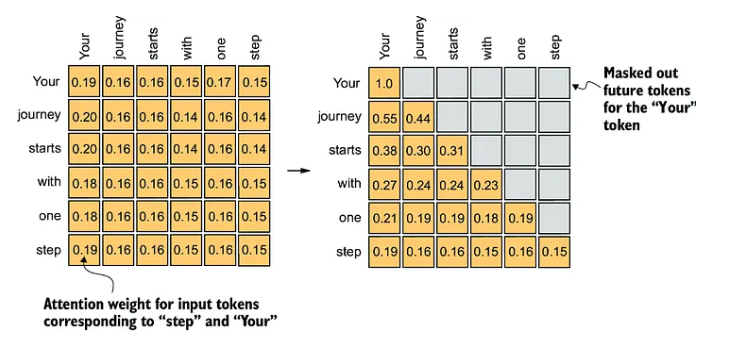

위 그림의 오른쪽처럼 attention weight matrix(attention score matrix 각 행에서 normalization까지 한 matrix)에서 주대각선 위의 attention weight를 masking 한 것이 causal attention mechanism에서의 attention weight matrix이다.

In [33]:
#위 그림의 오른쪽과 같은 masked attention weight matrix를 구해보자.
#먼저 기본적인 attention weight matrix를 구하겠다.

queries=Sa_v2.W_query(inputs)
keys=Sa_v2.W_key(inputs)
attn_scores=queries @ keys.T
attn_weights=torch.softmax(attn_scores/keys.shape[-1]**0.5,dim=-1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


In [34]:
#위에서 masking되지 않은 attention weight matrix를 구했는데, 이제 이를 masking해보겠다.
#trill 함수로 주대각선 위의 값이 0인 mask를 만들겠다.

context_length = attn_scores.shape[0]
mask_simple=torch.tril(torch.ones(context_length,context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [35]:
#이제 위에서 구한 mask와 attention weight matrix를 곱해 masked attention weight matrix를 구하겠다.
masked_simple=attn_weights*mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


In [36]:
#이제 이 masked attention weight matrix를 다시 normalization한다.
row_sums=masked_simple.sum(dim=-1,keepdim=True)
masked_simple_norm=masked_simple/row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


In [39]:
#masked attention weight matrix를 더 적은 단계에서 효율적으로 계산할 수 있는 방법은 다음과 같다.
#non-masked attention weight matrix를 구하기 전 단계인(normalization전 단계) non-masked attention score matrix에서
#먼저 주대각선 위의 값을 -∞로 masking한 뒤 softmax 함수를 적용시켜 normalization을 하게 되면, 바로 masked attention weight matrix를 구할 수 있다.

mask=torch.triu(torch.ones(context_length,context_length),diagonal=1)
print(mask)
print("\n\n--------------------------\n\n")
masked=attn_scores.masked_fill(mask.bool(),-torch.inf)
print(masked)
print("\n\n--------------------------\n\n")
#softmax 함수 적용시켜 normalization
attn_weights=torch.softmax(masked/keys.shape[-1]**0.5,dim=1)
print(attn_weights)

tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])


--------------------------


tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


--------------------------


tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]

In [40]:
#masked attention weight matrix로 context vecotr를 계산하기 이전에 LLM을 훈련할 때 overfitting을 줄이기 위해 필요한 추가 작업이 있다.
#training 중에 hidden layer의 node를 랜덤하게 선택하여 해당 node의 출력을 무시하는 기법인 dropout으로 attention weight에 추가적인 masking을 한다.
#dropout은 training 중에만 사용되며, 그 이후에는 비활성화된다.
#masked attention weight를 계산 후 혹은 value vector에 attention weight를 적용한 후에 dropout을 적용한다.
#여기서는 masked attention weight 계산한 후에 dropout mask를 적용하겠다(matrix내의 일부 attention weight를 0으로 만드는 것이다.).

torch.manual_seed(123)
dropout=torch.nn.Dropout(0.5) #dropout 비율을 50%로 지정한다.
example=torch.ones(6,6) #1로 채워진 matrix를 만든다.
print(dropout(example))

#dropout으로 삭제된 값을 남은 원소들로 보상하기 위해 matrix에서 남은 원소의 값을 1/0.5=2배로 늘린다.
#이런 보상을 통해 전반적인 attention weight의 균형을 유지한다.

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


In [41]:
#이제 masked attention weight matrix에 dropout을 적용해 보겠다.
torch.manual_seed(123)
print("dropout 적용전 matrix:")
print(attn_weights)
print("\ndropout 적용후 matrix:")
print(dropout(attn_weights))

dropout 적용전 matrix:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)

dropout 적용후 matrix:
tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)


In [42]:
#이제 causal attention mechanism에 대한 class를 구현해보겠다.
#위에서 만든 SelfAttention class에 causal attention과 dropout 기능을 추가하면 된다.

class CausalAttention(nn.Module):
  def __init__(self,d_in,d_out,context_length,dropout,qkv_bias=False):
    super().__init__()
    self.d_out=d_out
    self.W_query=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_key=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.W_value=nn.Linear(d_in,d_out,bias=qkv_bias)
    self.dropout=nn.Dropout(dropout)  #dropout layer추가
    self.register_buffer(
        'mask',
        torch.triu(torch.ones(context_length,context_length),
                   diagonal=1)
    )

  def forward(self,x):
    b,num_tokens,d_in=x.shape
    keys=self.W_key(x)
    queries=self.W_query(x)
    values=self.W_value(x)
    attn_scores=queries@keys.transpose(1,2)

    attn_scores.masked_fill(
        self.mask.bool()[:num_tokens,:num_tokens],-torch.inf
    )
    attn_weights=torch.softmax(
        attn_scores/keys.shape[-1]**0.5,dim=-1
    )
    attn_weights=self.dropout(attn_weights)

    context_vec=attn_weights@values
    return context_vec


In [43]:
batch=torch.stack((inputs,inputs),dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


In [44]:
torch.manual_seed(123)
context_length=batch.shape[1]
ca=CausalAttention(d_in,d_out,context_length,0.0)
context_vecs=ca(batch)
print("context_vecs.shape:",context_vecs.shape)

context_vecs.shape: torch.Size([2, 6, 2])


In [45]:
#이제 여러 개의 causal attention을 병렬로 구성한 multi head attention module을 구현해보겠다.
#이때 각 attention machanism은 독립적으로 동작한다. 즉 각자 고유한 weight matrix인 Wq,Wk,Wv를 갖고 있다.
#그리고 여러개 attention machanism에서 나온 출력(context vector)을 합칠 수 있다. 이를 통해 복잡한 패턴을 인식할 수 있다.
#다음은 multi head attention class를 구현한 것이다.

class MultiHeadAttentionWrapper(nn.Module):
  def __init__(self,d_in,d_out,context_length,
                 dropout,num_heads,qkv_bias=False): #num_heads 매개변수로 attention head의 개수를 지정한다.
    super().__init__()
    self.heads=nn.ModuleList(
        [CausalAttention(
           d_in,d_out,context_length,dropout,qkv_bias
        )
        for _ in range(num_heads)]
    )
  def forward(self,x):
    return torch.cat([head(x) for head in self.heads],dim=-1)

In [46]:
torch.manual_seed(123)
context_length=batch.shape[1]
d_in,d_out=3,2
mha=MultiHeadAttentionWrapper(
    d_in,d_out,context_length,0.0,num_heads=2
)
context_vecs=mha(batch)

print(context_vecs)
print("context_vecs.shape:",context_vecs.shape)

tensor([[[-0.5337, -0.1051,  0.5085,  0.3508],
         [-0.5323, -0.1080,  0.5084,  0.3508],
         [-0.5323, -0.1079,  0.5084,  0.3506],
         [-0.5297, -0.1076,  0.5074,  0.3471],
         [-0.5311, -0.1066,  0.5076,  0.3446],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.5337, -0.1051,  0.5085,  0.3508],
         [-0.5323, -0.1080,  0.5084,  0.3508],
         [-0.5323, -0.1079,  0.5084,  0.3506],
         [-0.5297, -0.1076,  0.5074,  0.3471],
         [-0.5311, -0.1066,  0.5076,  0.3446],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


#핵심 class

In [71]:
#MultiHeadAttentionWrapper와 CausalAttention class 2개를 하나의 class로 결합한다.
class MultiHeadAttention(nn.Module):
  def __init__(self, d_in,d_out,context_length,
               dropout,num_heads,qkv_bias=False):   #dropout은 dropout에 대한 비율이다.
    super().__init__()
    assert(d_out%num_heads==0),"d_out은 num_heads로 나누어 떨어져야 한다."
    #d_in은 inputs내 token의 차원 수이다.
    #d_out은 query, key, value vector의 차원 수
    self.d_out=d_out
    #multi head attention에서 head의 수
    self.num_heads=num_heads
    #각 head의 차원 수이다.
    self.head_dim=d_out//num_heads
    #query에 대한 하나의 거대한 weight matrix이다.
    self.W_query=nn.Linear(d_in,d_out,bias=qkv_bias)
    #key에 대한 하나의 거대한 weight matrix이다.
    self.W_key=nn.Linear(d_in,d_out,bias=qkv_bias)
    #value에 대한 하나의 거대한 weight matrix이다.
    self.W_value=nn.Linear(d_in,d_out,bias=qkv_bias)

    self.out_proj=nn.Linear(d_out,d_out)

    self.dropout=nn.Dropout(dropout)
    #mask는 context_length x context_length 크기인데, 이때 context_length는 한 문장내 tokens의 수이다.
    #주 대각선분을 포함하여 그 아래 원소는 0으로 이외 원소들은 1로 설정한다.
    self.register_buffer(
        "mask",
        torch.triu(torch.ones(context_length,context_length),diagonal=1)
    )

  def forward(self,x):
    #b는 batch size (=문장의 개수)
    #num_tokens은 하나의 문장 안에 들어있는 token들의 개수이다(=행의 수).
    #d_in은 각 token의 embedding vector의 차원을 의미한다(=열의 수).
    b,num_tokens,d_in=x.shape

    #self.W_key는 nn.Linear()에 대한 instance이다.
    #nn.Linear는 입력 x가 들어오면 내부적으로 자동으로 행렬곱을 수행한다.
    #x@w_key = key matrix
    keys=self.W_key(x)
    #x@w_query = query matrix
    queries=self.W_query(x)
    #x@w_value = value matrix
    values=self.W_value(x)

    #view()는 텐서의 차원을 조개고 재배치하는 함수이다.
    #keys의 원래 형태는 3차원 텐서로 (batch size, 한 문장 내 token 수, key embedding vector차원) = (b, num_tokens, d_out)이다.
    #(b, num_tokens, d_out)일 때 multi head attention에서 여러 개의 head가 각자 다른 관점으로 데이터를 보게하기 위해
    #d_out을 여러 갈래로 쪼개줘야한다. 그러기 위해 view함수를 사용해
    #(b, num_tokens, num_heads, head_dim)라는 4차원으로 변환하는 것이다(num_heads*head_dim=d_out).
    #이때 텐서의 모양을 쪼개 multi-head로 만들더라도, 서로 다른 문장들이 섞이거나,
    #문장 내 단어의 순서나 개수가 변하면 안되기 때문에 (b, num_tokens) 차원은 건드리지 않는다.
    #다만 embedding vector의 차원(d_out)은 변해도 상관 없기에 이를 num_heads와 head_dim으로 쪼개준 것이다.
    keys=keys.view(b,num_tokens,self.num_heads,self.head_dim)
    values=values.view(b,num_tokens,self.num_heads,self.head_dim)
    queries=queries.view(
        b,num_tokens,self.num_heads,self.head_dim
    )

    #(b, num_tokens, num_heads, head_dim)을 다음과 같이 transpose 해준다.
    #(b, num_heads, num_tokens, head_dim)
    #이유는 다음과 같다.
    #행렬곱 연산을 각 head별로 독립적이고 동시에 병렬 연산하기 위해서이다.
    #@라는 행렬곱 연산자는 3차원 이상의 텐서를 곱할 때, 가장 뒤에 있는 두 개의 차원만을 행렬로 간주하고
    #그 앞에 있는 차원들은 단순한 batch로 취급한다.
    #즉 b개의 batch안에 있는 num_heads개의 헤드들이 각각 자신만의 (num_tokens, head_dim) 크기의 행렬을 갖는다고 인식한다.
    keys=keys.transpose(1,2)
    queries=queries.transpose(1,2)
    values=values.transpose(1,2)

    #마찬가지로 queries는 (num_tokens, head_dim)이고,
    #keys.transpose(2,3)은 (head_dim, num_tokens)로 하여 행렬곱을 수행한다.
    #이때 pytorch의 행렬곱 연산자(@)가 내부적으로 모든 head의 연산을 병렬로 처리한다.
    #즉 각각 num_heads개의 head가 num_tokens x head_dim 크기의 matrix b개를 각 head에 따른 attention score를 계산하고,
    #각 head는 자신만의 query, key, value weight matrix을 학습하게 된다.
    #이론적으로는 위의 말이 맞지만 코드 상으로는 다음과 같이 작동한다.
    #큰 덩어리로 한 번에 곱한 뒤에, view로 차원을 잘라서 각 헤드에 할당해 준다.
    #그럼 각 head는 짤라진 것 중 자신에게 할당된 weight을 학습을 통해 최적화 한다.
    attn_scores=queries @ keys.transpose(2,3)
    mask_bool=self.mask.bool()[:num_tokens,:num_tokens]
    attn_scores.masked_fill_(mask_bool,-torch.inf)

    attn_weights=torch.softmax(
        attn_scores/keys.shape[-1]**0.5,dim=-1
    )
    attn_weights=self.dropout(attn_weights)

    #위에서 transpose하여 (b, num_heads, num_tokens, head_dim)을
    #다시 (b, num_tokens, num_heads, head_dim)으로 변환시킨다.
    context_vec=(attn_weights@values).transpose(1,2)

    #d_out을 num_heads와 head_dim으로 쪼갠 것을 다시 원상 복구 한다.
    #각각의 attention head들이 독립적으로 계산해 낸 결과물들을 단순히 옆으로 이어 붙인다.
    context_vec=context_vec.contiguous().view(
        b,num_tokens,self.d_out
    )

    #multi head attention에서 각 head는 문장을 서로 다른 관점(문법, 의미 감정 등)에서 독립적으로 분석한다.
    #위 코드에서는 이러한 분석을 단순히 이어 붙였기에 서로 다른 관점들이 서로 교류하지 못한다.
    #그래서 out_proj라는 선형 변환을 이용하여 8개의 head가 내놓은 각 정보들에 서로 다른 가중치가 곱해지고 더해지면서
    #최종적으로 하나로 잘 융합된 결론을 만든다.
    #거창하게 말했는데, 결국 학습가능한 matrix을 이용하여 위에서 단순히 이어붙인 행렬과 행렬곱하는 것이다.
    context_vec=self.out_proj(context_vec)
    return context_vec

In [48]:
a=torch.tensor([[[
    [0.2745,0.6584,0.2775,0.8573],
    [0.8993,0.0390,0.9268,0.7388],
    [0.7179,0.7058,0.9156,0.4840]],

    [[0.0772,0.3565,0.1479,0.5331],
     [0.4066,0.2318,0.4545,0.9737],
     [0.4606,0.5159,0.4220,0.5786]]]])

In [49]:
print(a@a.transpose(2,3))

tensor([[[[1.3208, 1.1631, 1.3308],
          [1.1631, 2.2150, 1.8793],
          [1.3308, 1.8793, 2.0861]],

         [[0.4391, 0.7003, 0.5903],
          [0.7003, 1.3737, 1.0620],
          [0.5903, 1.0620, 0.9912]]]])


In [50]:
first_head=a[0,0,:,:]
first_res=first_head@first_head.T
print("첫 번째 헤드:\n",first_res)

second_head=a[0,1,:,:]
second_res=second_head@second_head.T
print("\n두 번째 헤드:\n",second_res)

첫 번째 헤드:
 tensor([[1.3208, 1.1631, 1.3308],
        [1.1631, 2.2150, 1.8793],
        [1.3308, 1.8793, 2.0861]])

두 번째 헤드:
 tensor([[0.4391, 0.7003, 0.5903],
        [0.7003, 1.3737, 1.0620],
        [0.5903, 1.0620, 0.9912]])


In [72]:
torch.manual_seed(123)
batch_size,context_length,d_in=batch.shape
d_out=2
mha=MultiHeadAttention(d_in,d_out,context_length,0.0,num_heads=2)
context_vecs=mha(batch)
print(context_vecs)
print("context_vecs.shape:",context_vecs.shape)

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])


#요약
self-attention mechanism은 input sequence내의 임의의 한 token과 동일한 input sequence내의 모든 token사이의 관계를 담고 있는 context vector를 출력하는 동작을 모든 token에 대해 구하는 기법이다.

이때 self-attention mechanism의 입력으로는 embedding된 각 token에 대한 vector가 입력으로 들어온다.

    i번째 token embedding vector에 대한 context vector를 생성하는 과정을 보면서 self-attention mechanism의 과정을 살펴보겠다.
    self-attention mechanism은 training과정으로 값이 최적값으로 점점 갱신되는 3개의 weight matrix Wq,Wk,Wv를 갖고 있다.
    이 3개의 weight matrix는 모든 token에 대해 고정적인 값을 갖고 향후 GD과정에서 이 matrix내의 원소값들이 갱신된다.
    
    일단 input sequence내의 모든 token embedding vector와 Wq,Wk,Wv를 각각 행렬곱하여 각 token마다 자신 만의 query vector, key vector, value vector를 생성한다.
    i번째 query vector와 각 token마다의 key vector들을 각각 내적하여 각 token에 대한 실수값인 attention score를 구한다.
    그리고 softmax함수로 attention score을 normalization하여 attention weight를 구한다.
    이제 각 token에 대한 attention weight와 그 token의 value vector를 곱한 뒤 모든 token의 attention weight*value vector를 더한다.
    그럼 i번째 query에 대한 context vector를 구할 수 있다.

    이때 이러한 과정을 행렬로써 계산하게 되면, 모든 token에 대한 각각의 context vector를 더 효율적으로 구할 수 있다.
    그리고 attention weight matrix에 masking을 하게되면, causal attention mechanism이라 할 수 있고
    이러한 독립적인 attention mechanism head을 병렬적으로 연결하면 multi-head attention mechanism라 부른다.

#백지 구현
class MultiHeadAttention